# Deep Learning Assignment 2
#### By: Logan Justin Gunawan (S4096363)

## The Task:

I have built the company Litmus pty with my friend. Litmus pty runs studies on the deconstruction and analysis of memes and how they use certain psychological techniques to elicit a response from a viewer. Previously, we have done all of this analysis by hand, however, we would like to expand our reach by creating a model which automatically detects, what psychological techniques a meme uses, as well as what part of the meme specifically uses each technique. We have 22 possible techniques (listed under 'techniques_list_task3.txt') to choose from, + 1 for a meme which does not use any listed technique shown. Because a meme can use multiple techniques, or none at all, this is a multi-label classification task.

## Loading Libraries

In [ ]:
import torch
import torch.nn as nn   
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
import re, os, math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## The Data

In [4]:
LABELS = [  "Appeal to authority",
            "Appeal to fear/prejudice",
            "Black-and-white Fallacy/Dictatorship",
            "Causal Oversimplification",
            "Doubt",
            "Exaggeration/Minimisation",
            "Flag-waving",
            "Glittering generalities (Virtue)",
            "Loaded Language",
            "Misrepresentation of Someone's Position (Straw Man)",
            "Name calling/Labeling",
            "Obfuscation, Intentional vagueness, Confusion",
            "Presenting Irrelevant Data (Red Herring)",
            "Reductio ad hitlerum",
            "Repetition",
            "Slogans",
            "Smears",
            "Thought-terminating cliché",
            "Whataboutism",
            "Bandwagon",
            "Transfer",
            "Appeal to (Strong) Emotions"
]

dev_set_task1 = pd.read_json("data_2026_A2/data/dev_set_task1.txt")
dev_set_task2 = pd.read_json("data_2026_A2/data/dev_set_task2.txt")
test_set_task1 = pd.read_json("data_2026_A2/data/test_set_task1.txt")
test_set_task2 = pd.read_json("data_2026_A2/data/test_set_task2.txt")
train_set_task1 = pd.read_json("data_2026_A2/data/training_set_task1.txt")
train_set_task2 = pd.read_json("data_2026_A2/data/training_set_task2.txt")

all_set_task1 = pd.concat([dev_set_task1, train_set_task1, test_set_task1], 
                          axis = 0)

print(all_set_task1.dtypes)
print(len(all_set_task1))
all_set_task1.head()

id           str
labels    object
text         str
dtype: object
951


,id,labels,text
0,62_batch_2,[],"*President* Biden?\n\nPlease, no.\n"
1,111_batch_2,"[Loaded Language, Name calling/Labeling]","JOE VERSUS THE VOLCANIC KREMLIN DON\n\n""WILL ..."
2,167_batch_2,[],ANTI-VAXXERS BE LIKE... \n\nHANG ON A SEC - JU...
3,93_batch_2,[],VIRUS BINGO\nFREE 32 SPACE\n
4,153_batch_2,"[Exaggeration/Minimisation, Loaded Language, N...",Never thought l'd die fighting IRRESPONSIBLY R...


Text(0.5, 1.0, 'Label Distribution')

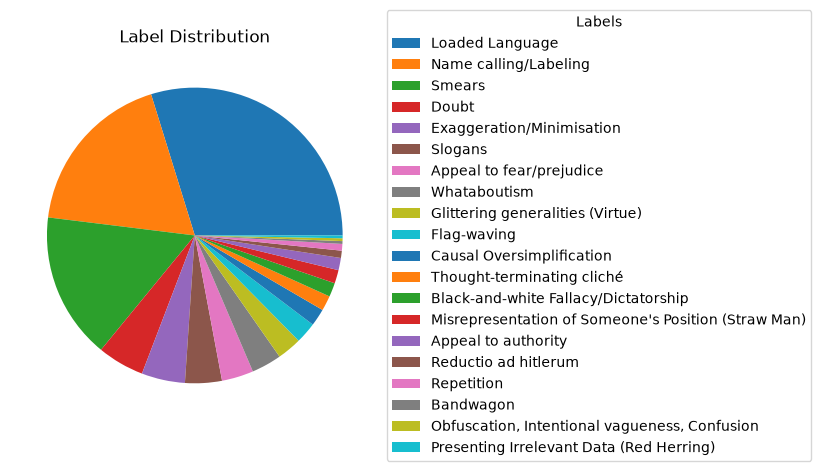

In [5]:
label_counts = Counter(
    label
    for labels in all_set_task1["labels"]
    for label in labels
)

label_counts_df = pd.DataFrame(label_counts.items(), columns = ["Label", "Count"]).sort_values(by = "Count", ascending = False)

wedges, _ = plt.pie(label_counts_df["Count"].values)

plt.legend(wedges,
           label_counts_df["Label"].values,
           title="Labels",
           bbox_to_anchor=(1, 0.5),
           loc="center left")

plt.title("Label Distribution")

Label weights for Task 1:
Appeal to authority: 2.41
Appeal to fear/prejudice: 0.73
Black-and-white Fallacy/Dictatorship: 1.74
Causal Oversimplification: 1.16
Doubt: 0.65
Exaggeration/Minimisation: 0.60
Flag-waving: 1.16
Glittering generalities (Virtue): 0.98
Loaded Language: 0.09
Misrepresentation of Someone's Position (Straw Man): 1.56
Name calling/Labeling: 0.14
Obfuscation, Intentional vagueness, Confusion: 7.82
Presenting Irrelevant Data (Red Herring): 31.27
Reductio ad hitlerum: 3.47
Repetition: 3.91
Slogans: 0.71
Smears: 0.16
Thought-terminating cliché: 1.56
Whataboutism: 0.78
Bandwagon: 15.64
Transfer: 0.00
Appeal to (Strong) Emotions: 0.00


Text(0.5, 1.0, 'Label Distribution')

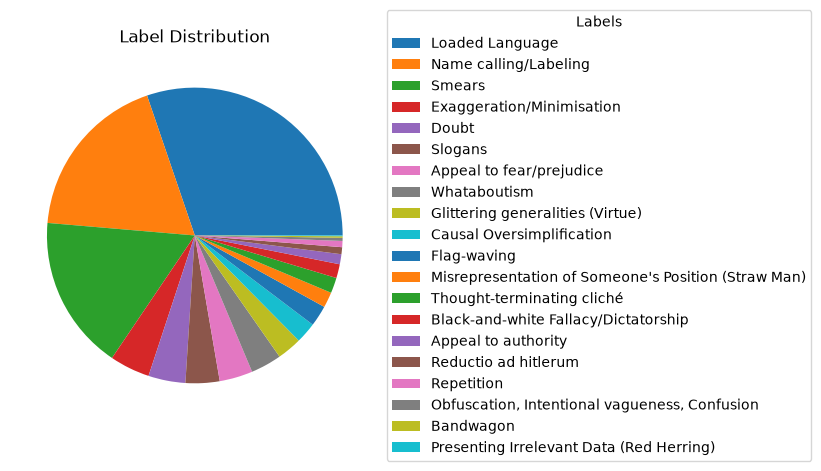

In [22]:
# Generating Label Weights
task1_label_counts = Counter(label
                             for labels in train_set_task1["labels"]
                             for label in labels)

total = len(train_set_task1)
total_labels = len(LABELS)

task1_label_weights = torch.tensor(
    [total / (total_labels * task1_label_counts[label]) 
     if task1_label_counts[label] > 0 else 0
     for label in LABELS],
    dtype=torch.float32
).to(device)

print('Label weights for Task 1:')
for i, name in enumerate(LABELS):
    print(f'{name}: {task1_label_weights[i].item():.2f}')

task1_label_counts_df = pd.DataFrame(task1_label_counts.items(), columns = ["Label", "Count"]).sort_values(by = "Count", ascending = False)

wedges, _ = plt.pie(task1_label_counts_df["Count"].values)

plt.legend(wedges,
           task1_label_counts_df["Label"].values,
           title="Labels",
           bbox_to_anchor=(1, 0.5),
           loc="center left")

plt.title("Label Distribution")

### Training Utilities (Adapted from Labs)

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, tokenizer_mode=False):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        if tokenizer_mode:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            y = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=y)
            loss = outputs.loss
            logits = outputs.logits
        else:
            x, y, lengths = batch
            x, y = x.to(device), y.to(device)
            logits = model(x, lengths)
            loss = criterion(logits, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * y.size(0)
        probabilities = nn.Sigmoid(logits)
        predicted = (probabilities >= 0.5).float()
        correct += (predicted == y).sum().item()
        total += y.numel()
    return total_loss / total, correct / total


def evaluate_model(model, loader, criterion, tokenizer_mode=False):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.inference_mode():
        for batch in loader:
            if tokenizer_mode:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                y = batch['labels'].to(device)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=y)
                loss = outputs.loss
                logits = outputs.logits
            else:
                x, y, lengths = batch
                x, y = x.to(device), y.to(device)
                logits = model(x, lengths)
                loss = criterion(logits, y)
            
            total_loss += loss.item() * y.size(0)
            _, predicted = torch.max(logits, 1)
            correct += (predicted == y).sum().item()
            total += y.size(0)
    return total_loss / total, correct / total


def run_experiment(model, optimizer, criterion, train_loader, val_loader,
                   epochs=10, name='Model', tokenizer_mode=False):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(epochs):
        tl, ta = train_one_epoch(model, train_loader, optimizer, criterion, tokenizer_mode)
        vl, va = evaluate_model(model, val_loader, criterion, tokenizer_mode)
        history['train_loss'].append(tl)
        history['train_acc'].append(ta)
        history['val_loss'].append(vl)
        history['val_acc'].append(va)
        if (epoch + 1) % max(1, epochs // 5) == 0 or epoch == 0:
            print(f'  [{name}] Epoch {epoch+1}/{epochs} — '
                  f'Train: {tl:.4f} / {ta:.4f} | Val: {vl:.4f} / {va:.4f}')
    return history


def plot_experiments(results, show_train=True, show_val=True):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for name, hist in results.items():
        epochs = range(1, len(hist['train_loss']) + 1)
        if show_train:
            axes[0].plot(epochs, hist['train_loss'], label=f'{name} (Train)', marker='o', markersize=3)
            axes[1].plot(epochs, hist['train_acc'], label=f'{name} (Train)', marker='o', markersize=3)
        if show_val:
            axes[0].plot(epochs, hist['val_loss'], label=f'{name} (Val)', linestyle='--', marker='x', markersize=3)
            axes[1].plot(epochs, hist['val_acc'], label=f'{name} (Val)', linestyle='--', marker='x', markersize=3)
    for ax, ylabel in zip(axes, ['Loss', 'Accuracy']):
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel); ax.set_title(ylabel)
        ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Task 1: Building the Detector

